Étape 1 : Initialisation et Inspection des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

#on charge les données
df = pd.read_csv('contexte_B_intrusion_reseau.csv')

#petite inspection de ligne et colonnes
print("Dimensions du DataFrame :", df.shape)

#on afficher les 5 premieres lignes
print("\n Affichage des 5 premières lignes")
display(df.head())

#on analyse les données (types de données, valeurs manquantes)
print("\n Informations sur le DataFrame")
df.info()

Dimensions du DataFrame : (494021, 42)

 Affichage des 5 premières lignes


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.



 Informations sur le DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised           

Étape 2 : Préparation des données (Feature Engineering & Échantillonnage)

In [2]:
from sklearn.preprocessing import StandardScaler

#on fait une binaristaion de la cible de façon à ce qu'on tranforme le trafic normal en 0 et les attaques en 1
y_raw = df['labels'].values
y_binary = np.array([0 if 'normal' in str(val) else 1 for val in y_raw])

# 2. Sous-échantillonnage pour simuler un vrai réseau 
np.random.seed(42) # Pour avoir toujours le même résultat
normal_indices = np.where(y_binary == 0)[0]
attack_indices = np.where(y_binary == 1)[0]

#on recrée un environnement où les attaques sont une minorité donc 50000 tafic normal et 2500 anomalie
sampled_normal = np.random.choice(normal_indices, 50000, replace=False)
sampled_attack = np.random.choice(attack_indices, 2500, replace=False)

final_indices = np.concatenate([sampled_normal, sampled_attack])
np.random.shuffle(final_indices) #on mélange 

#crée notre dataset final
df_sampled = df.iloc[final_indices].reset_index(drop=True)
y = y_binary[final_indices]
X = df_sampled.drop('labels', axis=1) # On retire la colonne cible des caractéristiques

print(f"Dataset réaliste créé : {len(y)} connexions (dont {np.sum(y==1)} attaques).")

#Encodage des variables textuelles
categorical_cols = ['protocol_type', 'service', 'flag']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
#on s'assure que les noms de colonnes sont bien des chaînes de caractères
X_encoded.columns = X_encoded.columns.astype(str) 

#Standardisation pour le calcul des distances en PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print(f"Dimensions après encodage et standardisation : {X_scaled.shape[1]} caractéristiques.")

Dataset réaliste créé : 52500 connexions (dont 2500 attaques).
Dimensions après encodage et standardisation : 83 caractéristiques.


Étape 3 et 4 : Modélisation et Évaluation des Performances

La PCA : Cette méthode va forcer le modèle à compresser la normalité du trafic via un goulot d'étranglement. Les attaques, qui ont une structure différente, se reconstruiront très mal.  
L'Isolation Forest : Ce modèle utilise des arbres de décision. une anomalie est isolée en très peu de coupes, tandis qu'une donnée normale nécessite beaucoup de coupes

Le Recall : C'est le taux d'attaques réellement repérées.  
La Precision : Sur les alertes levées, combien sont de vraies attaques

In [3]:
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

#Modélisation

print("Entraînement des modèles")

# Modèle 1 : PCA avec étranglement de 10 composantes
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_reconstructed = pca.inverse_transform(X_pca)

#reconstruction_errors est notre score d'anomalie
reconstruction_errors = np.mean((X_scaled - X_reconstructed)**2, axis=1)
scores_pca = reconstruction_errors

# Modèle 2 : Isolation forest et on informe le modèle du pourcentage d'anomalies (5%)
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
iso_forest.fit(X_scaled)

#un score élevé = une forte probabilité d'anomalie
scores_iforest_raw = iso_forest.decision_function(X_scaled)
scores_iforest = -scores_iforest_raw


#Évaluation
# Définition du seuil d'alerte au 95ème percentile (pour cibler les 5% les plus suspects)
threshold_pca = np.percentile(scores_pca, 95)
threshold_iso = np.percentile(scores_iforest, 95)

# Génération des prédictions (0 = normal, 1 = attaque)
y_pred_pca = (scores_pca >= threshold_pca).astype(int)
y_pred_iso = (scores_iforest >= threshold_iso).astype(int)

print("\nPERFORMANCES PCA")
print(classification_report(y, y_pred_pca, target_names=["Normal (0)", "Attaque (1)"]))

print("\nPERFORMANCES ISOLATION FOREST")
print(classification_report(y, y_pred_iso, target_names=["Normal (0)", "Attaque (1)"]))

Entraînement des modèles

PERFORMANCES PCA
              precision    recall  f1-score   support

  Normal (0)       0.95      0.95      0.95     50000
 Attaque (1)       0.07      0.08      0.07      2500

    accuracy                           0.91     52500
   macro avg       0.51      0.51      0.51     52500
weighted avg       0.91      0.91      0.91     52500


PERFORMANCES ISOLATION FOREST
              precision    recall  f1-score   support

  Normal (0)       0.96      0.96      0.96     50000
 Attaque (1)       0.26      0.28      0.27      2500

    accuracy                           0.93     52500
   macro avg       0.61      0.62      0.62     52500
weighted avg       0.93      0.93      0.93     52500



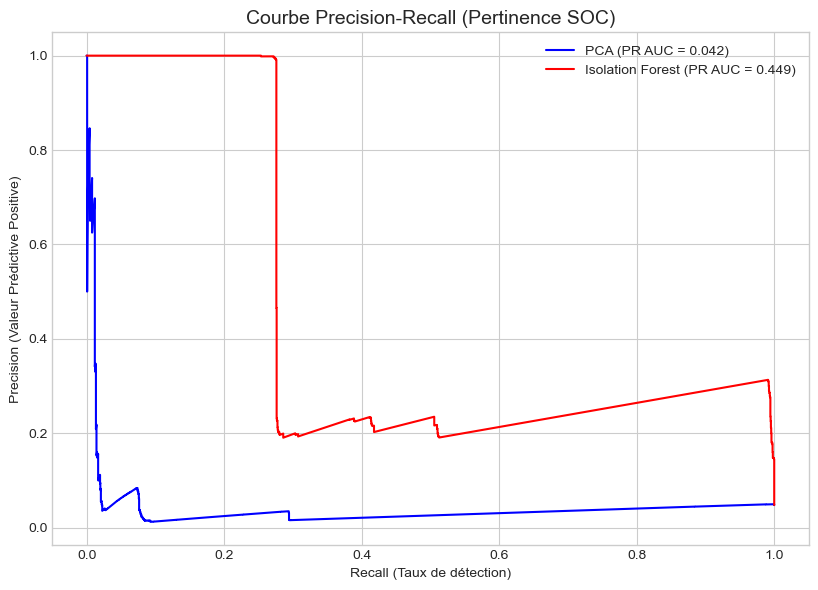


--- Profil des Anomalies isolées par l'Isolation Forest ---
Nombre d'attaques isolées : 691

Top 3 des protocoles utilisés par ces attaques :
protocol_type
tcp    690
udp      1
Name: count, dtype: int64

Top 3 des services réseau visés :
service
private     645
other        14
iso_tsap      3
Name: count, dtype: int64

Moyenne des caractéristiques clés pour ces intrusions :
duration        7.316932
src_bytes    7432.280753
dst_bytes       0.000000
count         192.486252
dtype: float64


In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# --- 1. VISUALISATION DES PERFORMANCES (Courbes ROC et PR) ---
plt.figure(figsize=(16, 6))

# Courbe Precision-Recall
plt.subplot(1, 2, 2)
precision_pca, recall_pca, _ = precision_recall_curve(y, scores_pca)
pr_auc_pca = auc(recall_pca, precision_pca)

precision_iso, recall_iso, _ = precision_recall_curve(y, scores_iforest)
pr_auc_iso = auc(recall_iso, precision_iso)

plt.plot(recall_pca, precision_pca, label=f'PCA (PR AUC = {pr_auc_pca:.3f})', color='blue')
plt.plot(recall_iso, precision_iso, label=f'Isolation Forest (PR AUC = {pr_auc_iso:.3f})', color='red')
plt.title('Courbe Precision-Recall (Pertinence SOC)', fontsize=14)
plt.xlabel('Recall (Taux de détection)')
plt.ylabel('Precision (Valeur Prédictive Positive)')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# --- 2. CARACTÉRISATION DES PROFILS RÉSEAUX ISOLÉS ---

# On récupère les Vrais Positifs (les vraies attaques que l'Isolation Forest a bien détectées)
true_positives_mask = (y == 1) & (y_pred_iso == 1)
df_anomalies_detectees = df_sampled[true_positives_mask]

print("\n--- Profil des Anomalies isolées par l'Isolation Forest ---")
print(f"Nombre d'attaques isolées : {len(df_anomalies_detectees)}")

# On regarde quels types de protocoles sont les plus utilisés par ces attaques
print("\nTop 3 des protocoles utilisés par ces attaques :")
print(df_anomalies_detectees['protocol_type'].value_counts().head(3))

# On regarde les services visés
print("\nTop 3 des services réseau visés :")
print(df_anomalies_detectees['service'].value_counts().head(3))

# On regarde la moyenne de quelques variables clés pour ces attaques
cols_of_interest = ['duration', 'src_bytes', 'dst_bytes', 'count']
print("\nMoyenne des caractéristiques clés pour ces intrusions :")
print(df_anomalies_detectees[cols_of_interest].mean())